### Simulating Euclid 2D spectra with GELSA 

In [1]:
# Show the node to which I'm connected: bld01, bld02, gpu03, ..
!hostname

mtx37


In [2]:
from matplotlib import pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

from gelsa import Gelsa
from gelsa import analysis
from gelsa import galaxy
from gelsa import visu

from astropy.io import fits
from astropy.table import Table
from astropy.constants import c
import astropy.units as u
import astropy.coordinates as coord
import astroquery 

from astroquery.vizier import Vizier

In [3]:
vizier = Vizier()
vizier.ROW_LIMIT = 1e6

The **2mass** catalog contains near IR data (JHK bands). We can use Vizier to query the catalog in the same region of the sky. Width and height are taken from NISP FOV. 

In [4]:
result = vizier.query_region(coord.SkyCoord(ra=150.1306739, dec=2.34,
                                            unit=(u.deg, u.deg),
                                            frame='icrs'),
                        width='0.763deg',
                        height='0.722deg',
                        catalog="II/246/out")
print(result)

TableList with 1 tables:
	'0:II/246/out' with 15 column(s) and 1009 row(s) 


In [5]:
result[0].info

<Table length=1009>
  name   dtype  unit  format                       description                       n_bad
------- ------- ---- -------- ------------------------------------------------------ -----
RAJ2000 float64  deg {:10.6f}                           (ra) Right ascension (J2000)     0
DEJ2000 float64  deg {:10.6f}                        (dec) Declination (J2000) (dec)     0
  2MASS   str17                                 (designation) Source designation (1)     0
   Jmag float32  mag  {:6.3f}                ?(j_m) J selected default magnitude (2)     0
 e_Jmag float32  mag  {:6.3f}         ?(j_msigcom) J total magnitude uncertainty (4)    12
   Hmag float32  mag  {:6.3f}                ?(h_m) H selected default magnitude (2)     0
 e_Hmag float32  mag  {:6.3f}         ?(h_msigcom) H total magnitude uncertainty (4)    18
   Kmag float32  mag  {:6.3f}                ?(k_m) K selected default magnitude (2)     0
 e_Kmag float32  mag  {:6.3f}         ?(k_msigcom) K total magnitude u

In [6]:
len(result[0])

1009

In order to convert from magnitude to a flux density in cgs, we need the zero points for the 3 bands. [Source](https://irsa.ipac.caltech.edu/data/SPITZER/docs/dataanalysistools/tools/pet/magtojy/ref.html)

$J_0 = 1594 \ Jy$ 

$H_0 = 1024 \ Jy$ 

$K_0 = 666.7 \ Jy$

In [7]:
Jmag = result[0]['Jmag']
Hmag = result[0]['Hmag']
Kmag = result[0]['Kmag']

In [10]:
J_0 = 1594
H_0 = 1024
K_0 = 666.7

Conversion formula: 

$$F_\nu = F_0 \ 10^{-m/2.5}$$

In [11]:
mag_to_flux = lambda m, f_0: f_0 * 10**(- m / 2.5)

In [12]:
flux_J = mag_to_flux(Jmag, J_0) * 1e-23 #specific flux in Jy * 10^-23 = specific flux in cgs
flux_H = mag_to_flux(Hmag, H_0) * 1e-23
flux_K = mag_to_flux(Kmag, K_0) * 1e-23

In [13]:
flux_J.shape

(1009,)

In [14]:
G = Gelsa(config_file='calib/gelsa_config.json')

The **flux** values are in $\mu Jy$ (microJansky), so they need to be converted into $erg \ s^{-1} \ cm^{-2} \ angstrom^{-1}$.

$1 \ \mu Jy = 10^{-29} \ erg \ s^{-1} \ cm^{-2} \ Hz^{-1}$

For energy conservation: $f_\lambda \ d\lambda = f_\nu \ d\nu$

So: $f_\lambda = f_\nu \ |\frac{d \nu}{d \lambda}| = f_\nu \ \frac{c}{\lambda^2}$

NB: c must be written in $angstrom \ s^{-1}$

>Center band values taken from: [*Jahnke, K., et al. "Euclid-III. The NISP Instrument." Astronomy & Astrophysics 697 (2025): A3.*](https://arxiv.org/pdf/2405.13493)

In [15]:
c_cgs = c.cgs.value

# I compute the conversion factor c/lambda^2
factor = lambda lam: (c_cgs*1e8)/(lam**2)

# Center wavelength values in angstrom
j_center =  13673
h_center = 17714

continuum_wavelength = np.linspace(12000, 19000, 100)

We want to do the image generation for 5 times so that we have around 100 images in total. 16 detectors x 7 $\sim$ 100

In [16]:
ra = result[0].field('RAJ2000')
dec = result[0].field('DEJ2000')

flux_j_lam = flux_J * factor(j_center)
flux_h_lam = flux_H * factor(h_center)

log_j_flux = np.log10(flux_j_lam)
log_h_flux = np.log10(flux_h_lam)

frame = G.new_spec_frame(ra=150.1306739, dec=2.34, pa=104.84, grism_name='RGS000', tilt=0, clear=True)

fluxes = []

for j in range(len(result[0])):
    x_pt = [j_center, h_center]
    y_pt = [log_j_flux[j], log_h_flux[j]]
    m, b = np.polyfit(x_pt, y_pt, 1)
    f = lambda x: m * np.array(x) + b
    y_val = f(continuum_wavelength)
    fluxes.append(y_val)
fluxes = np.array(fluxes)

loading ./calib/SIR_Calib_Opt_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000000-MT0S7VWE-20250123-180643-0-new_opt_cal-0.xml
loading ./calib/EUC_SIR_DETMODEL_REAL_DATA_OP_02.csv
loading ./calib/SIR_Calib_Ids_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000001-GQLJE83P-20250211-181132-0-new_ids_calib-0.xml
loading ./calib/SIR_Calib_Crv_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000001-6NJP8VE4-20250211-163247-0-new_crv_cal-0.xml


In [17]:
# continuum_wavelength = np.linspace(12000, 19000, 100)

In [18]:
from astropy.modeling.models import Gaussian1D

amp = 1
sigma = 70
new_f = []

for f in fluxes:
    central_wl = np.random.randint(13000, 18000)
    g = Gaussian1D(amplitude=amp, mean=central_wl, stddev=sigma)
    gauss_emission_line = g(continuum_wavelength)
    new_f.append(f + gauss_emission_line)

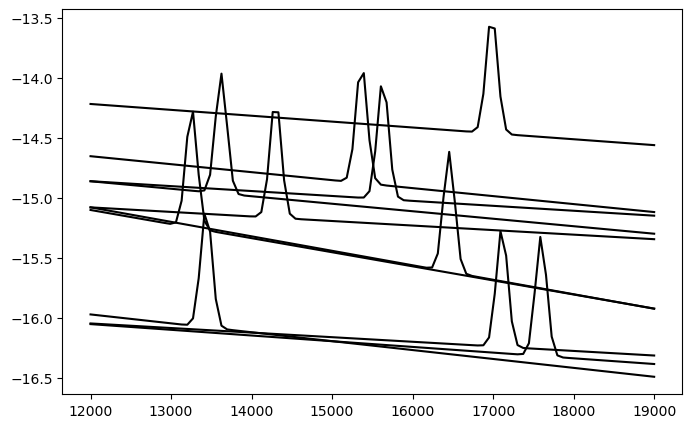

In [24]:
[plt.plot(continuum_wavelength, new_f[i], c='k') for i in range(10)];

We want to simulate the continuum + some emission lines. 

We rescale the fluxes by multiplying by $10^{-2}$, so that the max value of the emission lines now are around $10^{-15}$ and the continuum around $10^{-17}$.

In [25]:
sources = []

for k in range(len(result[0])):
# for k in range(100):
    source = galaxy.Galaxy(
        ra=ra[k],
        dec=dec[k],
        redshift=0,
        fwhm_arcsec=0.1,
        axis_ratio=1,
        continuum_params=(15000, -1e-5, -17),
        obs_wavelength_range=(12000, 19000)
    )
    continuum_flux = 10**(fluxes[k])
    source.set_sed(continuum_wavelength, continuum_flux)
    sources.append(source)
    
frame.add_sources(sources, noise=False)

alert weight=13.086894
alert weight=13.486408
alert weight=2.58554
alert weight=160.311768
alert weight=51.733548
alert weight=38.70649
alert weight=24.013262
alert weight=2.37763
alert weight=2.354336
alert weight=32.928412
alert weight=4.215822
alert weight=5.866656
alert weight=46.207048
alert weight=173.636558
alert weight=7.735214
alert weight=82.143858
alert weight=2.855952
alert weight=5.895264
alert weight=5.64378
alert weight=2.82877
alert weight=1.998234
alert weight=19.20585
alert weight=6.213988
alert weight=3.474166
alert weight=10.518948
alert weight=2.945666
alert weight=1.992572
alert weight=2.104654
alert weight=2.330408
alert weight=6.108022
alert weight=2.10065
alert weight=3.240786
alert weight=3.474268
alert weight=5.249018
alert weight=68.673868
alert weight=4.561536
alert weight=2.573402
alert weight=11.015374
alert weight=7.411638
alert weight=4.519806
alert weight=3.766912
alert weight=10.869918
alert weight=4.004982
alert weight=4.293566
alert weight=4.724236


In [48]:
images = []

for det in frame._data.keys():
    image, var, mask = frame.get_detector(det)
    images.append(image)

images = np.array(images)

In [49]:
frame._data.keys()

dict_keys([8, 4, 12, 13, 9, 14, 15, 0, 5, 1, 10, 6, 11, 2, 7, 3])

In [50]:
images.max()

13630528.748467831

In [51]:
full_well = 130000
images[images > full_well] = full_well
images.max()

130000.0

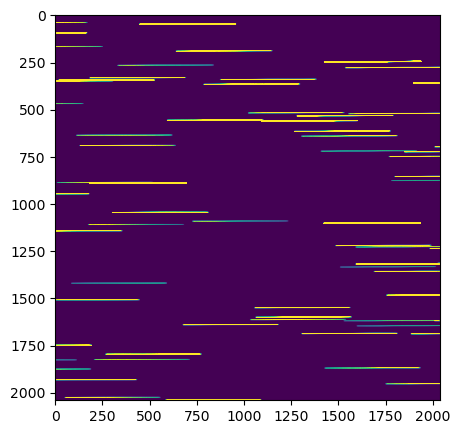

In [52]:
plt.imshow(images[5], vmin=0, vmax=5e2, aspect=1)

Save the images of the 16 detectors in a fits file

In [31]:
hdus = [fits.PrimaryHDU()]  # primary header
for i, img in tqdm(enumerate(images)):
    hdus.append(fits.ImageHDU(img, name=f"DET{i}"))
    hdul = fits.HDUList(hdus)
    hdul.writeto(f"16_detectors_images_highflux.fits", overwrite=True)

0it [00:00, ?it/s]

In [53]:
hdu_det = fits.open("16_detectors_images.fits", memmap=True)
hdu_det_lines = fits.open("16_detectors_images_lines.fits", memmap=True)
hdu_det_hf = fits.open("16_detectors_images_highflux.fits", memmap=True)

In [54]:
images_fits = np.array([hdu.data for hdu in hdu_det[1:]])
images_fits_lines = np.array([hdul.data for hdul in hdu_det_lines[1:]])
images_fits_hf = np.array([hdu.data for hdu in hdu_det_hf[1:]])

In [55]:
images_fits_lines.shape

(16, 2040, 2040)

Now we want to crop them:

In [56]:
def crop_into_rectangular_patches(img, patch_height, patch_width):
    h, w = img.shape
    # only keep the region that is divisible by patch size
    h_crop = (h // patch_height) * patch_height
    w_crop = (w // patch_width) * patch_width
    img_cropped = img[:h_crop, :w_crop]

    # reshape into patches
    patches = (
        img_cropped
        .reshape(h_crop // patch_height, patch_height, w_crop // patch_width, patch_width) 
        # the shape now is: (number of vertical patches, height of the vertical patch, # horizontal patches, width)
        .swapaxes(1, 2) # swap axis 1 with axis 2 so we have (numb, numb, height, width)
        .reshape(-1, patch_height, patch_width)
    )
    return patches

In [57]:
rect_images = []

for img in images_fits:
    patches = crop_into_rectangular_patches(img, 16, 512)
    rect_images.append(patches)

rect_images = np.array(rect_images)

In [60]:
rect_images_lines = []

for img in images_fits_lines:
    patches = crop_into_rectangular_patches(img, 16, 512)
    rect_images_lines.append(patches)

rect_images_lines = np.array(rect_images_lines)

In [61]:
rect_images_hf = []

for img in images_fits_hf:
    patches = crop_into_rectangular_patches(img, 16, 512)
    rect_images_hf.append(patches)

rect_images_hf = np.array(rect_images_hf)

In [62]:
rect_images_hf.shape

(16, 381, 16, 512)

In [65]:
rect_images = rect_images.reshape(-1, 16, 512) 
rect_images_lines = rect_images_lines.reshape(-1, 16, 512)
rect_images_hf = rect_images_hf.reshape(-1, 16, 512) 
rect_images_lines.shape

(6096, 16, 512)

In **rect_images** we have 6096 portions of image, each 500x10

Now we remove the blank images:

In [66]:
mask = ~(rect_images == 0).all(axis=(1, 2))

In [68]:
nonzero_images = rect_images[mask]
nonzero_images_lines = rect_images_lines[mask]
nonzero_images_hf = rect_images_hf[mask]

nonzero_images.shape

(1071, 16, 512)

Save the images into a **fits** file

In [69]:
hdus = [fits.PrimaryHDU()]  # primary header
for i, img in tqdm(enumerate(nonzero_images)):
    hdus.append(fits.ImageHDU(img, name=f"IM{i}"))
    hdul = fits.HDUList(hdus)
    hdul.writeto(f"simulated_rectangular_images.fits", overwrite=True)

0it [00:00, ?it/s]

In [ ]:
hdus = [fits.PrimaryHDU()]  # primary header
for i, img in tqdm(enumerate(nonzero_images_lines)):
    hdus.append(fits.ImageHDU(img, name=f"IM{i}"))
    hdul = fits.HDUList(hdus)
    hdul.writeto(f"simulated_rectangular_images_lines.fits", overwrite=True)

In [ ]:
hdus = [fits.PrimaryHDU()]  # primary header
for i, img in tqdm(enumerate(nonzero_images_hf)):
    hdus.append(fits.ImageHDU(img, name=f"IM{i}"))
    hdul = fits.HDUList(hdus)
    hdul.writeto(f"simulated_rectangular_images_hf.fits", overwrite=True)

In [46]:
hdu_rect = fits.open("simulated_rectangular_images.fits", memmap=True)
hdu_rect_lines = fits.open("simulated_rectangular_images_lines.fits", memmap=True)
hdu_rect_hf = fits.open("simulated_rectangular_images_hf.fits", memmap=True)

In [47]:
loaded_rect = np.array([hdu.data for hdu in hdu_rect[1:]])
loaded_rect_lines = np.array([hdu.data for hdu in hdu_rect_lines[1:]])
loaded_rect_hf = np.array([hdu.data for hdu in hdu_rect_hf[1:]])

In [467]:
loaded_rect_lines.shape

(1548, 10, 500)

In [232]:
hdu_rect.close()
hdu_rect_lines.close()